# QICK-DAWG Demo Notebook JNRS



In [1]:
# If setup.py installed, run this to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks


C:\Users\BurkeLab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qd.start_client('172.16.26.5') #RFSoC 4x2 IP address

KeyboardInterrupt: 

# Assigning Default Configurations for Pulsing: NVConfiguration <a class="anchor" id="first-bullet"></a>

In [3]:
default_config = qd.NVConfiguration()

# SPD counting configuration
default_config.adc_channel = 0 # SPD connected to ADC_D (ADC_C if 1)
default_config.edge_counting = True
default_config.high_threshold = 2000 
default_config.low_threshold = 500

# MW configuration
default_config.mw_channel = 0 # MW output at DAC_B (DAC_A if 1)
default_config.mw_nqz = 1 # Nyquist zone for the microwave generator. 1 for f < fdss/2 and 2 for f> fdss/2
default_config.mw_gain = 5000 # Effectively mw amplitude. From 0 to 32767

# Laser configuration
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 50 # Delay time at the end of a pulse sequence


AttributeError: module 'qickdawg' has no attribute 'soccfg'

Time units can be declared with a suffix "_tns", "_tus", or "_treg". <br>
Frequency units can be declared with suffixes "_fMHz", "_fGHz", or "_freg".<br>
Phase units can be declared with suffixes "_pdegrees" or "_preg".

These values are automatically converted to one another when assigned as part of the .NVConfiguration object.  For example, assiging `default_config.relax_delay_treg = 500 ` immediately assigns `default_config.relax_delay_tus = 1.220703125` and `default_config.relax_delay_tns = 1220.703125`.  

## Turn your laser on

Sets the laser_gate_pmod to its high value without turning off. This qickdawg.laser_on also returns the average ADC value for the duration of the "on" time.  The default is 65655 register values. which is approximately 100us.

In [11]:
qd.laser_on(default_config)

0

## Turn Laser off

The opposite of laser_on.  qickdawg.laser_off is that turns the laser_gate_pmod to its low value thus turning the laser off. the output of this function is the average value read by the ADC when the laser is off. 

In [35]:
qd.laser_off(default_config)

2171.9969634546424

# Get the readout window, check TTL thresholds

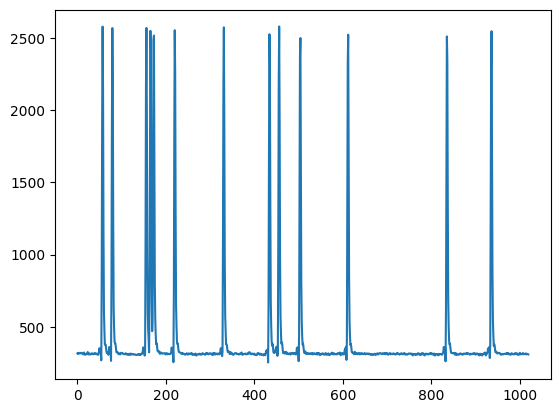

In [22]:
data = qd.check_readout(default_config)
plt.plot(data)

# Photoluminescence (PL) Intensity <a class="anchor" id="third-bullet"></a>

Here's where we actually start our "pulse sequencing". PL intensity is much like qd.LaserOn, but turns the laser off afterwards. The intent of this function is to not only get a value of photoluminescence intensity from the ADC, but also to also gather the PL intensity repeatedly and show live updated results for microscope alignment.

## Configuration and Getting a Single Data Point of PL Intensity

In [ ]:
config = copy(default_config)

config.readout_integration_treg = 2**16-1 # Maxium number of integrated points
config.reps = 1 

prog = qd.PLIntensity(config) 
counts = prog.acquire()

print('{} photons counted'.format(counts))
print('{} cps'.format(counts / qd.max_int_time_treg / qd.min_time_tns * 1e9))
print('{} Mcps'.format(counts / qd.max_int_time_treg / qd.min_time_tns * 1e9 / 1e6))

2377 photons counted
11142357.51888304 cps
11.14235751888304 Mcps


## Plotting the Sequence with Attribute Values

In the next cell we show how to plot the sequence with the variable values, by simply passing the NVConfiguration instance to the plot_sequence() class function

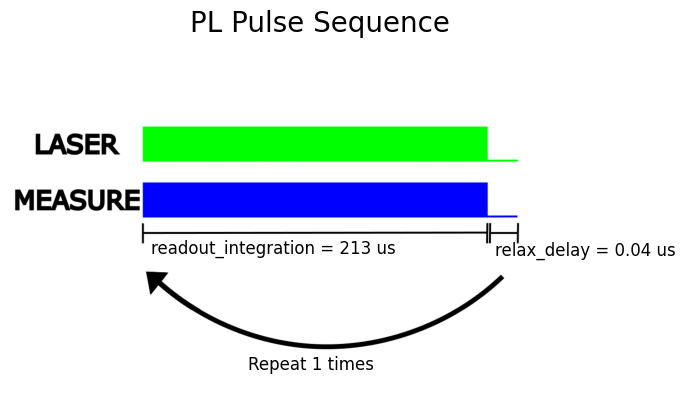

In [34]:
qd.PLIntensity.plot_sequence(config)

## PL Intensity Live

By making a lambda function that returns the PL intensity and using our qickdawg.live_plot function we can repeatedly measure the PL intensity and show the value on an updated plot. This is extremely useful for maximizing PL intensity while aligning your microscope. To exit, stop the currently executing cell using your JupyterNotebook server or press 'CTRL+C'

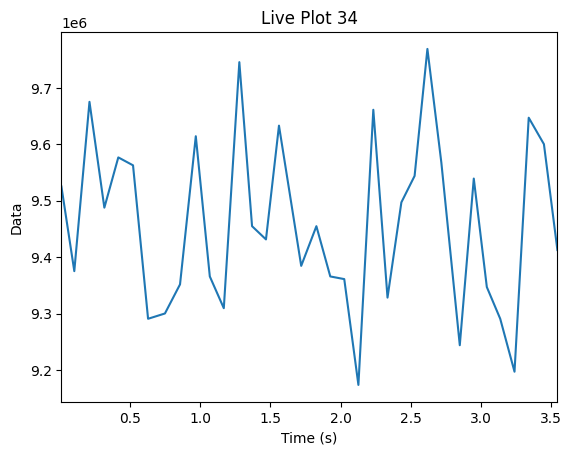

In [53]:
config = copy(default_config)

config.readout_integration_treg = 2**16-1 # Maxium number of integrated points
config.reps = 1 

prog = qd.PLIntensity(config) 

def get_cps():

    d = prog.acquire(progress=False)

    return d / qd.max_int_time_treg / qd.min_time_tns * 1e9


qd.live_plot(get_cps)

# Dark Counts

In [ ]:
config = copy(default_config)

config.readout_integration_treg = 2**16-1 # Maxium number of integrated points
config.reps = 10

prog = qd.DarkCounts(config) 
counts = prog.acquire()

print('{} dark counts'.format(counts))
print('{} dark cps'.format(counts / qd.max_int_time_treg / qd.min_time_tns * 1e9 / config.reps))
print('{} dark Mcps'.format(counts / qd.max_int_time_treg / qd.min_time_tns * 1e9 / 1e6 / config.reps))

45 dark counts
21094.071869993135 dark cps
0.021094071869993132 dark Mcps


# Optically detected magnetic resonance spectrum <a class="anchor" id="fourth-bullet"></a>

This qickdawg program is our first example of a "sweep", which performs a measurement while changing an experimental parameter. In this case, we make two measurements of photoluminescence one with our microwave output on and one with our output off.  The microwave frequency is the swept and we obtain an ODMR spectrum.

## Configuration, Measurement, and Plotting

In [ ]:
config = copy(default_config)

config.readout_integration_tus = qd.max_int_time_tus #Integration and pulse duration time
config.mw_gain = 10000 #MW amplitude
config.pre_init = True #True = initialize the spin state with a preliminary laser pulse, false = no preliminary initialization laser pulse
config.reps = 500 #Number of times to repeat the frequency sweep
config.relax_delay_treg = 500

config.add_linear_sweep('mw', 'fMHz', start=2700, stop=3000, delta=1) #MW sweep

prog = qd.LockinODMR(config)

d = prog.acquire() 
# Measurement, object d includes:
#.frequencies: the frequencies swept over
#.signal: PL intensity with the microwave output on
#.reference: PL intensity with the microwave output off
#.contrast: reference-signal
#.contrast_percent: (reference-signal)/reference * 100%



Requested 2700 to 3000 by 1
Instead using 2700.0 to 2999.999885559082 by 0.9999996185302734 in 301 steps


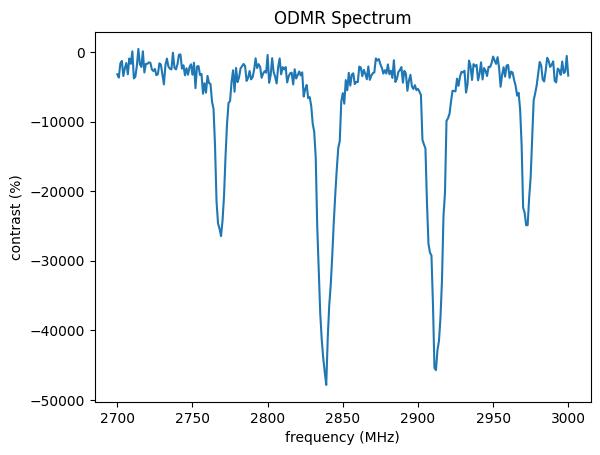

In [64]:
plt.plot(d.frequencies, d.contrast)

plt.title('ODMR Spectrum')
plt.ylabel('contrast (%)')
plt.xlabel('frequency (MHz)')

plt.show()

[2838.99994698 2911.99991913 2768.99997368 2971.99989624]


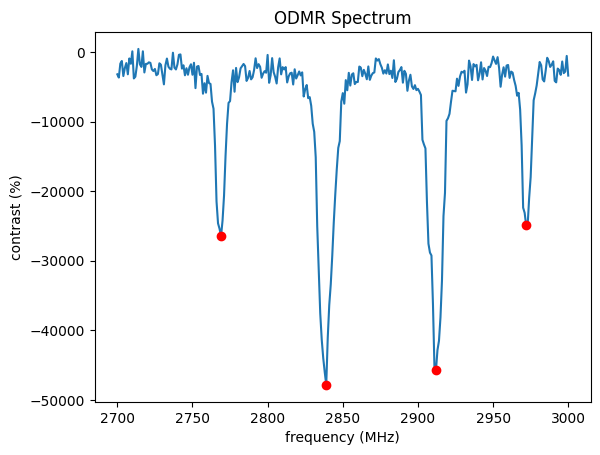

In [65]:
# fit to find peak value
num_peaks=4
def find_peaks(signal):
    # Find peaks using a simple NumPy-based approach
    peaks = np.where((signal[:-2] < signal[1:-1]) & (signal[1:-1] > signal[2:]))[0] + 1
    sorted_peaks = sorted(peaks, key=lambda p: d.contrast[p])
    peaks_corrected=sorted_peaks[:num_peaks]
    return peaks_corrected
peaks=find_peaks(-d.contrast)

plt.plot(d.frequencies, d.contrast)

plt.plot(d.frequencies[peaks], d.contrast[peaks], 'ro', label='Peaks')
plt.title('Signal with Peaks')
plt.title('ODMR Spectrum')
plt.ylabel('contrast (%)')
plt.xlabel('frequency (MHz)')

print(d.frequencies[peaks])



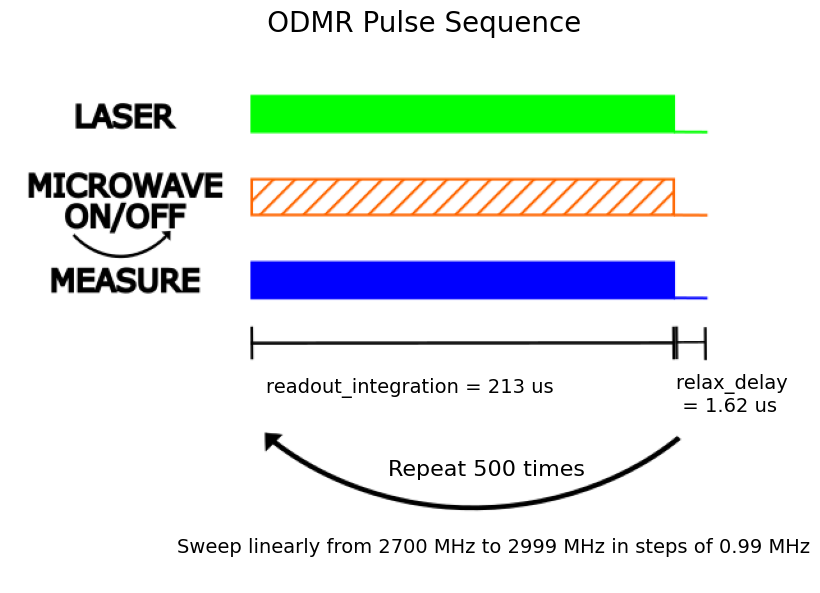

In [66]:
# Plot the pulse sequence with attribute values
qd.LockinODMR.plot_sequence(config)

## Live plot ODMR spectrum

Similarly to PLIntensity, we can also use `qickdawg.live_plot()` to repeatedly plot the ODMR spectrum.  This is particularly useful when manually adjusting magnetic field alignment.

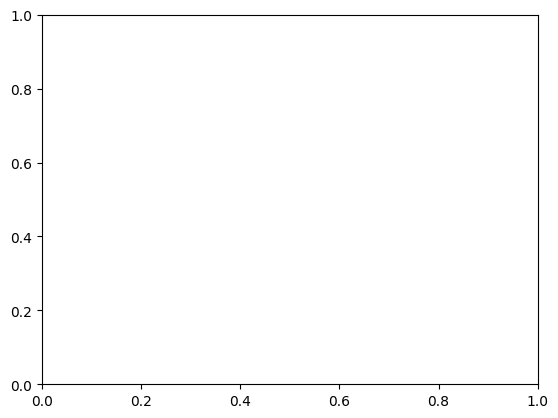

In [20]:
def get_spectrum():
   d = prog.acquire()
   return d.frequencies, d.odmr

qd.live_plot(get_spectrum)

# 4. Calibrate the Readout Window <a class="anchor" id="fifth-bullet"></a>
The ODMR spectrum, obtained in the last pulse sequence, helps us determine the frequency of the NV transition which we wish to pulse on and will be assigned to the configuration config.mw_f#. With this frequency setting, we then calibrate our NV spin readout window.  Here we look for two parameters: the delay between triggering our laser source (which will be assigned to config.laser_readout_offset_t#) and the optimal reatodut integration time, which is given by the time constant for repumping the NVs into the ms=0 state. 

All of this is accomplished by qd.get_readout_window() which acquires time traces of PL with and without a microwave pulse. Due to initial memory limitations of QICK, we acquire time domain data over several time doimain windows which have a maximum size of ~1020 data points, spanning approximately 2.6 microseconds. Each window is acquired through a qd.ReadoutWindow() class which is generated and handled by the qd.get_readout_window function as shown below. 

## 4a. Configuration, Measurement, Plotting, and Fitting
The readout window pulse sequence requires the following new configuration attributes in addition to the default configuration:

- .mw_pi2_t# - approximate pi/2 pulse, used to give spin contrast in the readout window. 
- .mw_f# - pulsing frequency for the microwave channel

- .readout_length_t# - length of time series readout, tyipcally 1020 reg
- .laser_initialize_t# - total time for the laser to be on and should be sufficiently long to initilze spins to ms=0
- .mw_readout_delay_t# - buffer time between the end of the microwave pulse and the beginning of the readout, a few 100 ns is typically sufficient and depends on the experimental setup
- .laser_readout_offset_t# - time between the trigger of the laser and the beginning of the readout, as seen by the adc (to be calibrated in this sequence, initially set to 0)
- .soft_avgs - number of repititions to average over
- .reps = 1, time domain data can only be taken on rep at a time if the total readout length is 1020 points
- .pre_init = True, is extremely important for this sequence because the time between soft averages is sufficiently long that there is appreciable T1 relaxation and spins must be reinitialized before pulsing


In [118]:
config = copy(default_config)

config.mw_gain = 30000
config.mw_fMHz = 2768
config.mw_pi2_tus = 100

config.pre_init=True

config.relax_delay_tus=0.5

config.laser_on_tus = 15 # in us
config.readout_integration_tns = 50  # us
config.readout_reference_start_tus = 10 # us

config.mw_readout_delay_treg = 35
config.laser_readout_offset_treg = 0

config.reps=1000

for i in range(40):

    config.laser_readout_offset_treg = i * config.readout_integration_treg

    prog = qd.IntegratedReadoutWindow(config)

    d = prog.acquire()

    if i ==0:
        results = d
        results.delay = np.array([config.laser_readout_offset_treg])
    else:
        for key in d.keys():
            results[key] = np.append(results[key], d[key])
        results.delay = np.append(results.delay, [config.laser_readout_offset_treg])

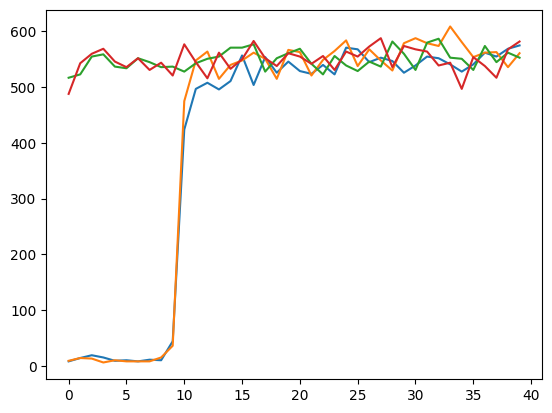

In [119]:
plt.plot(results.signal1)
plt.plot(results.signal2)
plt.plot(results.reference1)
plt.plot(results.reference2)

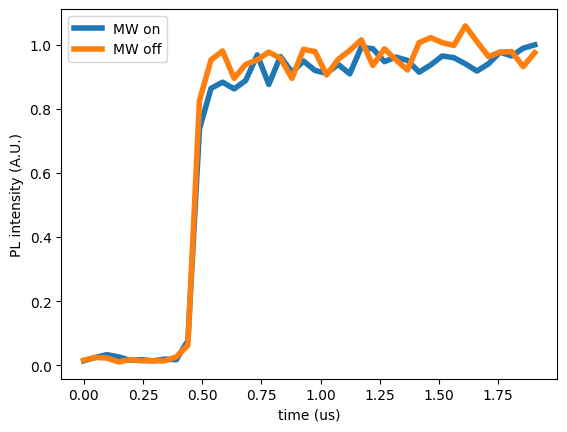

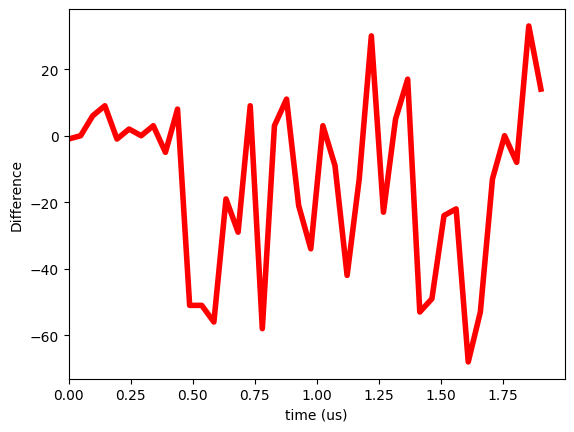

laser_readout_offset is approximately 165 register units


In [123]:
# Here we plot the readout window data for the microwave pluse on and the microwave off
data_off = results.signal2
data_on = results.signal1

t = np.array(results.delay) * qd.min_time_tus
x = data_on
x2 = data_off

plt.plot(t, x/np.max(x), linewidth=4)
plt.plot(t, x2/np.max(x), linewidth=4) 

plt.legend(['MW on', 'MW off'])
plt.xlabel('time (us)')
plt.ylabel('PL intensity (A.U.)')
# plt.xlim(0, 190)
# plt.ylim(0, 1.1)
plt.show()

plt.plot(t, x - x2, c='red', linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, )
plt.show()

print('laser_readout_offset is approximately {} register units'.format(results.delay[np.where(x/np.max(x) > 0.8)[0][0]]))


In [134]:
config = copy(default_config)

config.mw_gain = 30000
config.mw_fMHz = 2768
config.mw_pi2_tus = 100

config.pre_init=True

config.relax_delay_tus=0.5

config.laser_on_tus = 15 # in us
config.readout_integration_tns = 100  # us
config.readout_reference_start_tus = 10 # us

config.mw_readout_delay_treg = 35

config.reps=5000

for i in range(20):

    config.laser_readout_offset_treg = i * config.readout_integration_treg + 150

    prog = qd.IntegratedReadoutWindow(config)

    d = prog.acquire()

    if i ==0:
        results = d
        results.delay = np.array([config.laser_readout_offset_treg])
    else:
        for key in d.keys():
            results[key] = np.append(results[key], d[key])
        results.delay = np.append(results.delay, [config.laser_readout_offset_treg])

## 4b Fitting the Readout Window Data

After calibrating the laser_readout_offset, we want to find the pumping time from our initial spin state to m<sub>s</sub>=0.  We find this value by fitting the difference between microwave on and microwave off data to an exponential decay.  The extracted time constant tau can then be used to determine our readout_integration_t#, which is 1xtau, and the total laser pumping time which should be at least 5xtau.

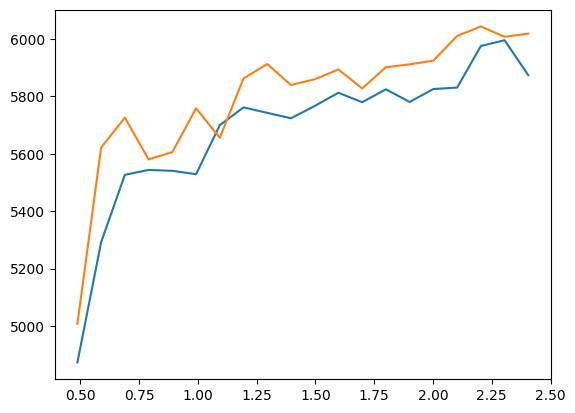

In [137]:
plt.plot(results.delay * qd.min_time_tus, results.signal1)
plt.plot(results.delay * qd.min_time_tus, results.signal2)

[6.38322472e+02 2.99803850e-01 9.17669143e+01]


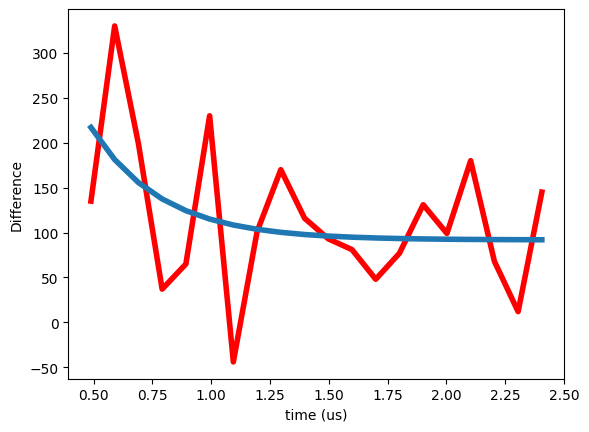

In [138]:
data_off = results.signal2
data_on = results.signal1

x = (data_off-data_on)
t = np.array(results.delay) * qd.min_time_tus

plt.plot(t, x, linewidth=4, color='red')

param, _ = curve_fit(qd.exponential_decay, t, x, p0=[800, 0.8, 100])

plt.plot(t, qd.exponential_decay(t, *param), linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
# plt.xlim(0, )
# plt.ylim(0, )
print(param)

# 5 Rabi Oscillations <a class="anchor" id="seventh-bullet"></a>
After calibrating the readout window by getting laser_readout_offset_t# and readout_integration_t#, the last step before pulse sequencing is to calibrate the microwave pi/2 pulse length.  Microwave pi/2 pulse length calibration is determined by a rabi oscialltion pulse sequence where we initilize our spins to ms=0, vary the length of a microwave pulse, and readout the spin projection of our NVs. 

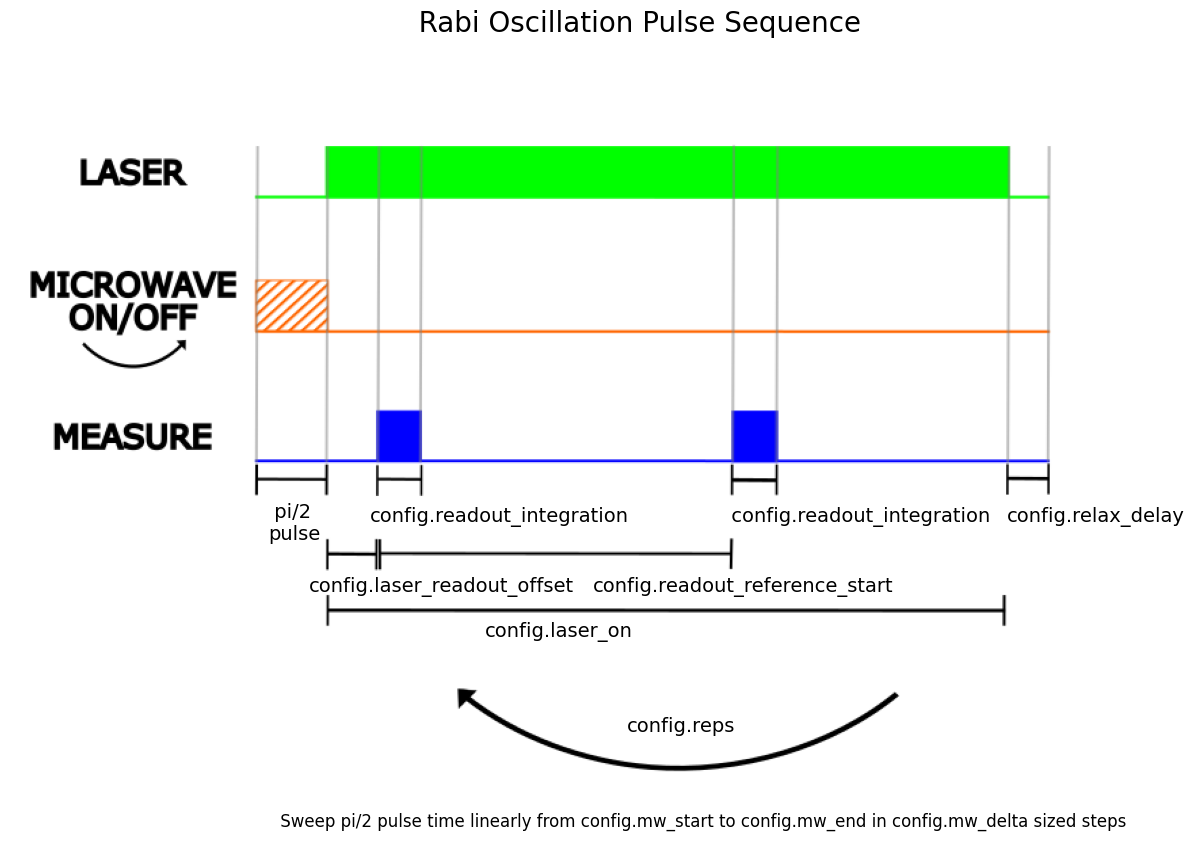

In [139]:
qd.RabiSweep.plot_sequence()

## 5a. Configuration, Measurment, and Plotting <a class="anchor" id="seventh-bullet"></a>

For our Rabi Oscillations we again copy the default_config and assign some familiar parameters, but also some new ones.  Most specifically we highlight that we have now added:

- add_linear_sweep('mw', 'treg', start=4, stop=800, delta=4) - a helper function that generates the required sweep parameters to change the microwave pulse length from the start value to the end value in steps of delta. 
- .readout_integration_t# - The amount of time to integrate at the beginning of the readout window as our "signal"

In [157]:
config = copy(default_config)

config.relax_delay_tus=1

config.mw_gain = 30000
config.mw_fMHz = 2768

config.pre_init=True

config.relax_delay_tus=0.5

config.laser_on_tus = 20 # in us
config.readout_integration_tus = 2  # us
config.readout_reference_start_tus = 10 # us

config.mw_readout_delay_treg = 35
config.laser_readout_offset_treg = 150 #

config.add_linear_sweep('mw', 'treg', start=4, stop=204, delta=4)

config.reps = 50000

prog = qd.RabiSweep(config)
d = prog.acquire(progress=True)


  0%|          | 0/2550000 [00:00<?, ?it/s]

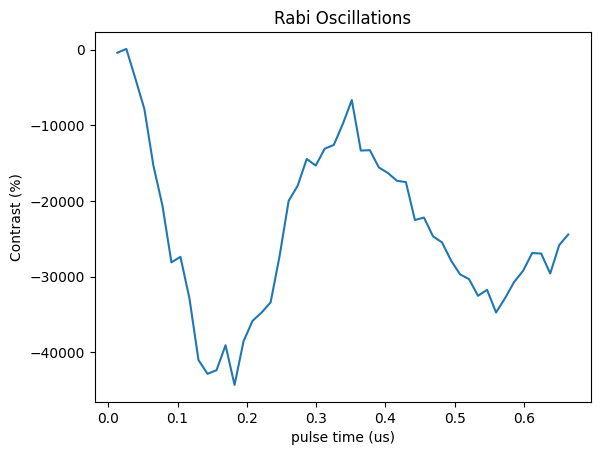

In [158]:
plt.plot(d.sweep_tus, d.contrast)

plt.title('Rabi Oscillations')
plt.ylabel('Contrast (%)')
plt.xlabel('pulse time (us)')
plt.show()


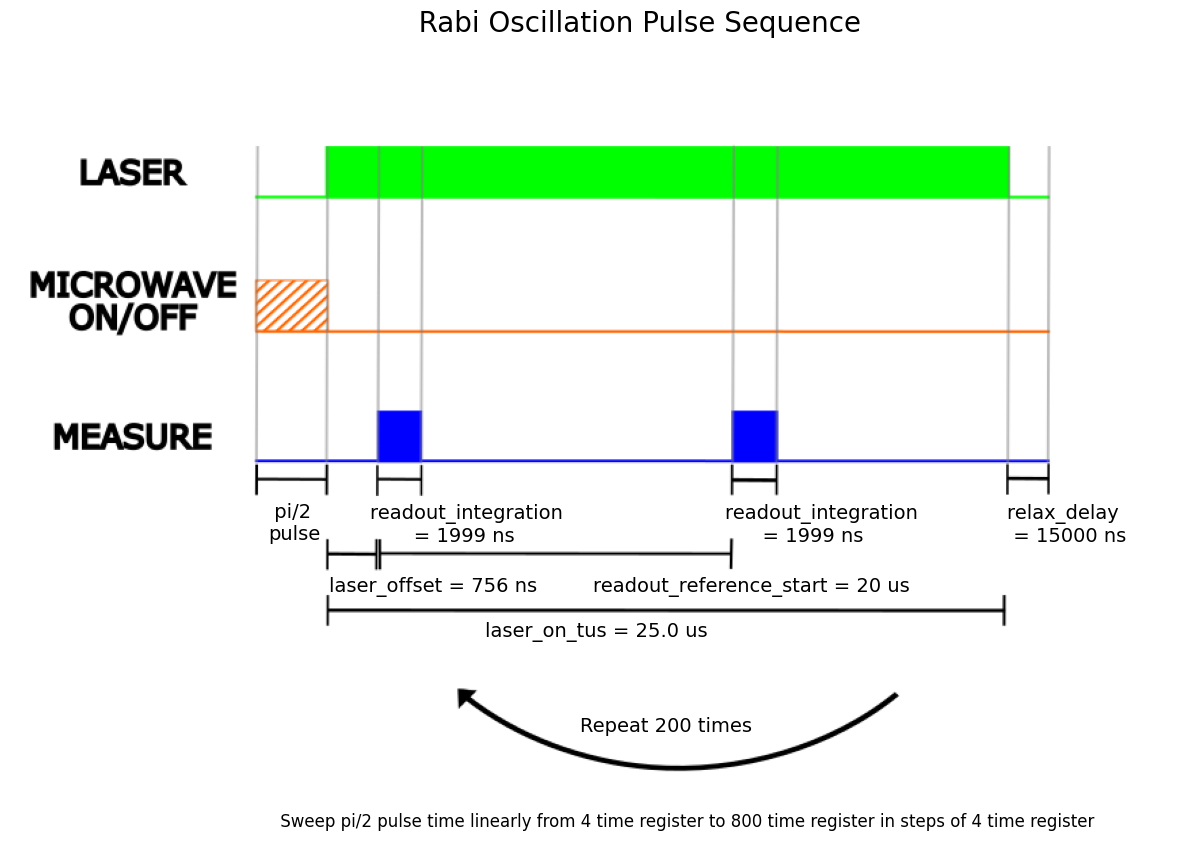

In [ ]:
qd.RabiSweep.plot_sequence(config)


In [163]:
def decaying_cos(x, A, T, tau):

    return -A /2 * (np.cos(x*2*np.pi/T- np.pi))*np.exp(-x/tau) - A/2

Pi/2 pulse is approximately 91 ns


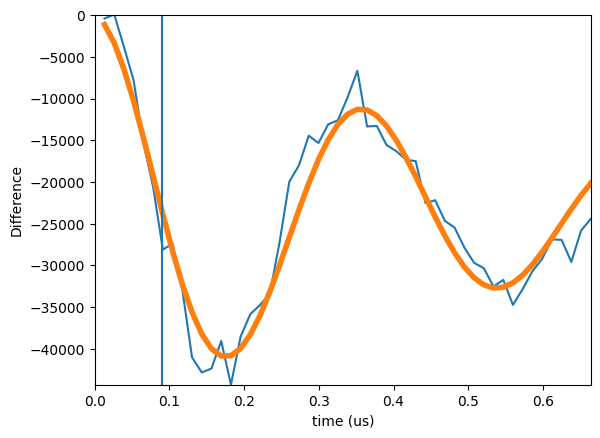

In [167]:
p0 = [-40000, 0.3, 0.5]

t = d.sweep_tus
x = d.contrast

param, _ = curve_fit(decaying_cos, t, x, p0 = p0)

plt.plot(d.sweep_tus, d.contrast)

plt.plot(t, decaying_cos(t, *param), linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, np.max(t))
plt.ylim(np.min(x), 0)
print('Pi/2 pulse is approximately {:.0f} ns'.format(param[1]*1000/4))
plt.vlines(param[1]/4, np.min(d.contrast), 0)

